In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!nvidia-smi


Mounted at /content/drive
Wed Dec 10 09:38:58 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   60C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+---------------------

Create a working copy of the dataset to avoid modifying the original data.

In [ ]:
import os
import shutil

# Original directories
orig_train = '/content/drive/MyDrive/MRI Images/Training/'
orig_test = '/content/drive/MyDrive/MRI Images/Testing/'

# Working directory
working_dir = '/content/drive/MyDrive/MRI Images/WorkingCopy/'
os.makedirs(working_dir, exist_ok=True)

# New paths
new_train = os.path.join(working_dir, 'Training/')
new_test = os.path.join(working_dir, 'Testing/')

# Copy (only if not already present)
if not os.path.exists(new_train):
    shutil.copytree(orig_train, new_train)
else:
    print("Training folder already exists.")

if not os.path.exists(new_test):
    shutil.copytree(orig_test, new_test)
else:
    print("Testing folder already exists.")

print("Dataset duplicated successfully!")


Training folder already exists.
Testing folder already exists.
Dataset duplicated successfully!


In [ ]:
!pip install timm albumentations==1.4.3 opencv-python matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.0/137.0 kB 13.0 MB/s eta 0:00:00
  Attempting uninstall: albumentations
    Found existing installation: albumentations 2.0.8
    Uninstalling albumentations-2.0.8:
      Successfully uninstalled albumentations-2.0.8


In [ ]:
import os
import shutil
import cv2
import timm
import torch
import numpy as np
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader
from torch import nn
from tqdm import tqdm


Define paths for training and testing datasets from the working directory.

In [ ]:
import os

# Use your already-prepared working dataset
dst_root  = "/content/drive/MyDrive/MRI Images/WorkingCopy"
dst_train = f"{dst_root}/Training"
dst_test  = f"{dst_root}/Testing"

# Check if folders exist
if not os.path.exists(dst_train) or not os.path.exists(dst_test):
    print("❌ ERROR: WorkingCopy Training/Testing folders not found!")
else:
    print("✔ Using existing WorkingCopy dataset.")
    print("Training path:", dst_train)
    print("Testing path :", dst_test)


✔ Using existing WorkingCopy dataset.
Training path: /content/drive/MyDrive/MRI Images/WorkingCopy/Training
Testing path : /content/drive/MyDrive/MRI Images/WorkingCopy/Testing


Apply data augmentation techniques to improve model generalization.

In [ ]:
train_transform = A.Compose([
    A.Resize(256, 256),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.RandomBrightnessContrast(p=0.3),
    A.ShiftScaleRotate(shift_limit=0.03, scale_limit=0.05,
                       rotate_limit=10, p=0.4),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(256, 256),
    ToTensorV2(),
])


Resizing and normalization

In [ ]:
class BrainMRIDataset(Dataset):
    def __init__(self, folder, transform=None):
        self.transform = transform
        self.paths = []
        self.labels = []

        classes = sorted(os.listdir(folder))
        self.class_to_idx = {c:i for i,c in enumerate(classes)}

        for c in classes:
            cfolder = os.path.join(folder, c)
            for f in os.listdir(cfolder):
                self.paths.append(os.path.join(cfolder, f))
                self.labels.append(self.class_to_idx[c])

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = cv2.imread(self.paths[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        if self.transform:
            img = self.transform(image=img)["image"]

        img = img.float() / 255.0  # normalize to [0,1]

        # IMAGENET normalization
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
        std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
        img = (img - mean) / std

        label = self.labels[idx]
        return img, label


Create DataLoaders

In [ ]:
train_dataset = BrainMRIDataset(dst_train, transform=train_transform)
val_dataset   = BrainMRIDataset(dst_test,  transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=32,
                          shuffle=True, num_workers=4,
                          pin_memory=True, persistent_workers=True)

val_loader = DataLoader(val_dataset, batch_size=32,
                        shuffle=False, num_workers=4,
                        pin_memory=True, persistent_workers=True)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Initialize Model and Training Setup

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = timm.create_model("efficientnet_b0",
                          pretrained=True,
                          num_classes=4).to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=12)

scaler = torch.cuda.amp.GradScaler()


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

/tmp/ipython-input-407195977.py:11: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


Training Loop

In [ ]:
epochs = 15
best_acc = 0

for epoch in range(epochs):
    model.train()
    train_correct = 0
    train_total = 0

    loop = tqdm(train_loader, total=len(train_loader), desc=f"Epoch {epoch+1}/{epochs}")

    for imgs, labels in loop:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():
            outputs = model(imgs)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        _, preds = outputs.max(1)
        train_correct += preds.eq(labels).sum().item()
        train_total += labels.size(0)

    scheduler.step()
    train_acc = train_correct / train_total

    # ---- Validation ----
    model.eval()
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            out = model(imgs)
            preds = out.argmax(1)
            val_correct += preds.eq(labels).sum().item()
            val_total += labels.size(0)

    val_acc = val_correct / val_total

    print(f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

    if val_acc > best_acc:
        torch.save(model.state_dict(), "best_model_fast.pth")
        best_acc = val_acc


Epoch 1/15:   0%|          | 0/179 [00:00<?, ?it/s]/tmp/ipython-input-4182880593.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 1/15: 100%|██████████| 179/179 [07:29<00:00,  2.51s/it]


Train Acc: 0.8202 | Val Acc: 0.9336


Epoch 2/15: 100%|██████████| 179/179 [00:48<00:00,  3.70it/s]


Train Acc: 0.9402 | Val Acc: 0.9756


Epoch 3/15: 100%|██████████| 179/179 [00:48<00:00,  3.66it/s]


...

Train Acc: 0.9983 | Val Acc: 0.9962


Epoch 14/15: 100%|██████████| 179/179 [00:46<00:00,  3.83it/s]


Train Acc: 0.9972 | Val Acc: 0.9962


Epoch 15/15: 100%|██████████| 179/179 [00:46<00:00,  3.83it/s]


Train Acc: 0.9972 | Val Acc: 0.9962


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np
import torch

model.eval()

all_labels = []
all_preds = []
all_probs = []

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)

        probs = torch.softmax(outputs, dim=1).cpu().numpy()
        preds = np.argmax(probs, axis=1)

        all_labels.extend(labels.numpy())
        all_preds.extend(preds)
        all_probs.extend(probs)


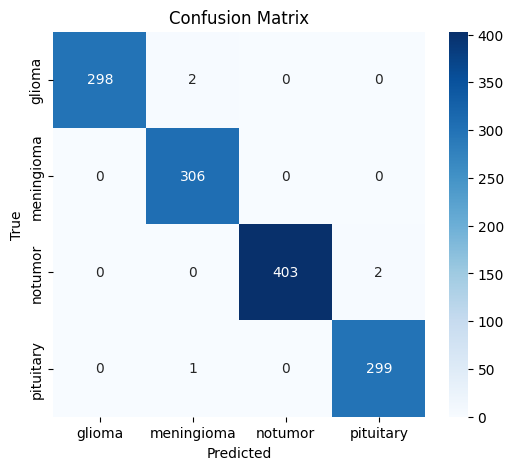

In [ ]:
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=train_dataset.class_to_idx.keys(),
            yticklabels=train_dataset.class_to_idx.keys())
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


In [ ]:
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=train_dataset.class_to_idx.keys()))



Classification Report:
              precision    recall  f1-score   support

      glioma       1.00      0.99      1.00       300
  meningioma       0.99      1.00      1.00       306
     notumor       1.00      1.00      1.00       405
   pituitary       0.99      1.00      1.00       300

    accuracy                           1.00      1311
   macro avg       1.00      1.00      1.00      1311
weighted avg       1.00      1.00      1.00      1311



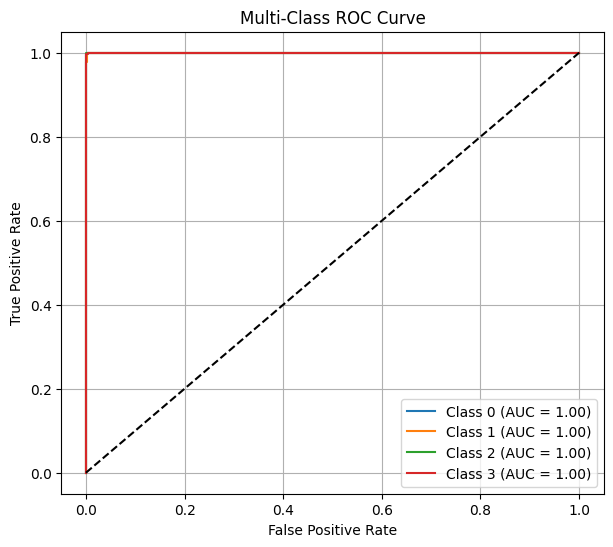

In [ ]:
from sklearn.metrics import roc_curve, auc

# Convert labels → one-hot
y_true = label_binarize(all_labels, classes=list(range(4)))
y_score = np.array(all_probs)

fpr = {}
tpr = {}
roc_auc = {}

n_classes = 4

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC
plt.figure(figsize=(7,6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC = {roc_auc[i]:.2f})")

plt.plot([0,1], [0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-Class ROC Curve")
plt.legend()
plt.grid()
plt.show()


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

accuracy = accuracy_score(all_labels, all_preds)
precision_macro = precision_score(all_labels, all_preds, average='macro')
recall_macro = recall_score(all_labels, all_preds, average='macro')
f1_macro = f1_score(all_labels, all_preds, average='macro')

precision_weighted = precision_score(all_labels, all_preds, average='weighted')
recall_weighted = recall_score(all_labels, all_preds, average='weighted')
f1_weighted = f1_score(all_labels, all_preds, average='weighted')


print(f" Accuracy    : {accuracy:.4f}")
print(f" Precision   : {precision_macro:.4f}")
print(f" Recall      : {recall_macro:.4f}")
print(f" F1 Score    : {f1_macro:.4f}\n")



 Accuracy    : 0.9962
 Precision   : 0.9959
 Recall      : 0.9963
 F1 Score    : 0.9961



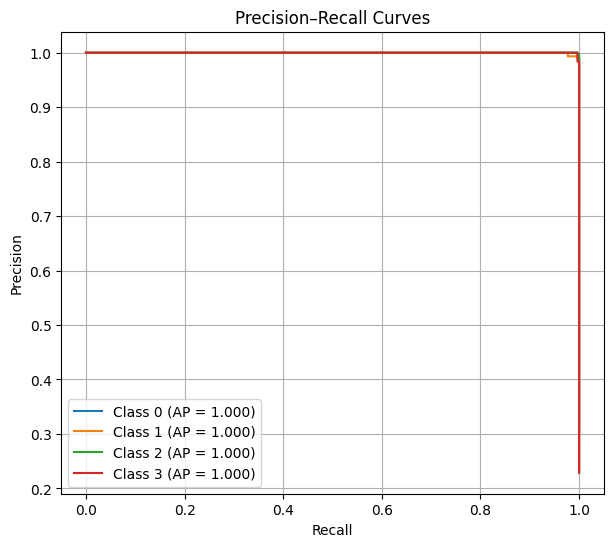

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(7,6))

for i in range(n_classes):
    precision, recall, _ = precision_recall_curve(y_true[:, i], y_score[:, i])
    ap = average_precision_score(y_true[:, i], y_score[:, i])

    plt.plot(recall, precision, label=f"Class {i} (AP = {ap:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curves")
plt.legend()
plt.grid()
plt.show()


Save the trained model to Google Drive for future use.

In [ ]:
!mkdir -p "/content/drive/MyDrive/MRI Images/Models"


In [ ]:
import torch

save_path = "/content/drive/MyDrive/MRI Images/Models/best_model_fast.pth"
torch.save(model.state_dict(), save_path)

print(f"✔ Model saved successfully to: {save_path}")


✔ Model saved successfully to: /content/drive/MyDrive/MRI Images/Models/best_model_fast.pth
